# Social Computing: Notebook 6 &ndash; Data Analysis and Visualization

For educational purposes only; this notebook will **not** be graded.

Author: Jonas Zellweger (jonas.zellweger@uzh.ch)

## Introduction

<img src="https://imgs.xkcd.com/comics/insomnia.png" alt="Insomnia">

We are working with a synthetic **Sleep Health and Lifestyle** dataset, which could be obtained from [Kaggle](https://www.kaggle.com). It contains fictional data about sleep disorders and several features that could be related to it.


In [2]:
# Import the pandas library to work with Dataframes
import pandas as pd

## 1) Data Preparation

In [3]:
# Read the csv into a pandas Dataframe
sleep_filepath = "Sleep_health_and_lifestyle_dataset.csv"
sleep_df = pd.read_csv(sleep_filepath)

In [4]:
# Examine the data
sleep_df.head(n=10).style

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.100000,6,42,6,Overweight,126/83,77,4200,nan
1,2,Male,28,Doctor,6.200000,6,60,8,Normal,125/80,75,10000,nan
2,3,Male,28,Doctor,6.200000,6,60,8,Normal,125/80,75,10000,nan
3,4,Male,28,Sales Representative,5.900000,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.900000,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.900000,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.300000,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.800000,7,75,6,Normal,120/80,70,8000,nan
8,9,Male,29,Doctor,7.800000,7,75,6,Normal,120/80,70,8000,nan
9,10,Male,29,Doctor,7.800000,7,75,6,Normal,120/80,70,8000,nan


Wait... Why do we have 'nan' (not a number) in the `Sleep Disorder` column?

In [5]:
# Let's examine the NaN counts
sleep_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


What should we do? Should we just drop the NaN's?

In [6]:
# Drop all rows that have a nan value somewhere (don't worry, it's not in-place – our original data is safe)
sleep_df.dropna()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
16,17,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [7]:
# What would that do to our data?
sleep_df.dropna().info()

<class 'pandas.DataFrame'>
Index: 155 entries, 3 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                155 non-null    int64  
 1   Gender                   155 non-null    str    
 2   Age                      155 non-null    int64  
 3   Occupation               155 non-null    str    
 4   Sleep Duration           155 non-null    float64
 5   Quality of Sleep         155 non-null    int64  
 6   Physical Activity Level  155 non-null    int64  
 7   Stress Level             155 non-null    int64  
 8   BMI Category             155 non-null    str    
 9   Blood Pressure           155 non-null    str    
 10  Heart Rate               155 non-null    int64  
 11  Daily Steps              155 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 17.0 KB


That would leave us with less than half the data...
Maybe not the best idea. Let's examine a bit more

In [8]:
# Show unique values for 'Sleep Disorder'
sleep_df["Sleep Disorder"].unique()

<StringArray>
[nan, 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str

&rArr; Let's look at the raw data:

In [9]:
with open(sleep_filepath, "r") as f:
    for i in range(10):
        print(f.readline().strip())

Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None
9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None


```text
Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None
9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None
```

&rArr; Apparently, `pd.read_csv` interprets 'None' as 'not a number' (NaN). We need to change this:

In [10]:
# Add a parameter that tells read_csv to not parse strings as NaN
sleep_df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv", keep_default_na=False)

# Examine the data again
sleep_df.head(n=10).style

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.100000,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.200000,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.200000,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.900000,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.900000,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.900000,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.300000,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.800000,7,75,6,Normal,120/80,70,8000,None
8,9,Male,29,Doctor,7.800000,7,75,6,Normal,120/80,70,8000,None
9,10,Male,29,Doctor,7.800000,7,75,6,Normal,120/80,70,8000,None


In [11]:
# Check the data again
sleep_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


#### One advantage of using pandas Dataframes
Pandas provides us with some statistical data out of the box:

In [12]:
# Get statistical information
sleep_df.describe().style

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


Apparently, `describe()` only includes numerical values. But we can change this behavior:

In [13]:
# Include all columns; statistical values are only provided where it is possible/meaningful
sleep_df.describe(include="all").style

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,374
unique,nan,2,nan,11,nan,nan,nan,nan,4,25,nan,nan,3
top,nan,Male,nan,Nurse,nan,nan,nan,nan,Normal,130/85,nan,nan,None
freq,nan,189,nan,73,nan,nan,nan,nan,195,99,nan,nan,219
mean,187.500000,nan,42.184492,nan,7.132086,7.312834,59.171123,5.385027,nan,nan,70.165775,6816.844920,nan
std,108.108742,nan,8.673133,nan,0.795657,1.196956,20.830804,1.774526,nan,nan,4.135676,1617.915679,nan
min,1.000000,nan,27.000000,nan,5.800000,4.000000,30.000000,3.000000,nan,nan,65.000000,3000.000000,nan
25%,94.250000,nan,35.250000,nan,6.400000,6.000000,45.000000,4.000000,nan,nan,68.000000,5600.000000,nan
50%,187.500000,nan,43.000000,nan,7.200000,7.000000,60.000000,5.000000,nan,nan,70.000000,7000.000000,nan
75%,280.750000,nan,50.000000,nan,7.800000,8.000000,75.000000,7.000000,nan,nan,72.000000,8000.000000,nan


### What could be improved?

In [14]:
# Recall
sleep_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


#### 1. Some columns should be categorical (instead of str):

- Gender
- Occupation
- BMI Category
- Sleep Disorder

In [15]:
# Define the features we want to change and store this list for later
categorical_features = ["Gender", "Occupation", "BMI Category", "Sleep Disorder"]
# Let's see how many unique values we have for each of these features
print(sleep_df[categorical_features].nunique())

Gender             2
Occupation        11
BMI Category       4
Sleep Disorder     3
dtype: int64


In [16]:
# Make a deep copy of our dataframe to store the original dataframe for later comparison
sleep_df_original = sleep_df.copy()

# Convert string columns to categorical data
sleep_df[categorical_features] = sleep_df[categorical_features].astype("category")
sleep_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [17]:
# What has changed?
sleep_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Person ID                374 non-null    int64   
 1   Gender                   374 non-null    category
 2   Age                      374 non-null    int64   
 3   Occupation               374 non-null    category
 4   Sleep Duration           374 non-null    float64 
 5   Quality of Sleep         374 non-null    int64   
 6   Physical Activity Level  374 non-null    int64   
 7   Stress Level             374 non-null    int64   
 8   BMI Category             374 non-null    category
 9   Blood Pressure           374 non-null    str     
 10  Heart Rate               374 non-null    int64   
 11  Daily Steps              374 non-null    int64   
 12  Sleep Disorder           374 non-null    category
dtypes: category(4), float64(1), int64(7), str(1)
memory usage: 28.0 KB


#### 2. Split blood pressure
- Create 2 additional columns: `BP High` and `BP Low`
- Split `Blood Pressure` by the slash character

In [18]:
# We could perform an operation on all values of a specific column
sleep_df["Blood Pressure"].apply(lambda x: x.split("/"))

0      [126, 83]
1      [125, 80]
2      [125, 80]
3      [140, 90]
4      [140, 90]
         ...    
369    [140, 95]
370    [140, 95]
371    [140, 95]
372    [140, 95]
373    [140, 95]
Name: Blood Pressure, Length: 374, dtype: object

We can use the string function on a Dataframe column:

In [19]:
sleep_df["Blood Pressure"].str.split("/")

0      [126, 83]
1      [125, 80]
2      [125, 80]
3      [140, 90]
4      [140, 90]
         ...    
369    [140, 95]
370    [140, 95]
371    [140, 95]
372    [140, 95]
373    [140, 95]
Name: Blood Pressure, Length: 374, dtype: object

... and expand the arrays into additional columns:

In [20]:
sleep_df["Blood Pressure"].str.split("/", expand=True)

,0,1
0,126,83
1,125,80
2,125,80
3,140,90
4,140,90
...,...,...
369,140,95
370,140,95
371,140,95
372,140,95


Now, putting it all together and store it within the Dataframe:

In [21]:
# Split the blood pressure string values and append them to the dataframe
sleep_df[["BP High", "BP Low"]] = sleep_df["Blood Pressure"].str.split("/", expand=True)
sleep_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP High,BP Low
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95


In [22]:
# Check the data types again
sleep_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Person ID                374 non-null    int64   
 1   Gender                   374 non-null    category
 2   Age                      374 non-null    int64   
 3   Occupation               374 non-null    category
 4   Sleep Duration           374 non-null    float64 
 5   Quality of Sleep         374 non-null    int64   
 6   Physical Activity Level  374 non-null    int64   
 7   Stress Level             374 non-null    int64   
 8   BMI Category             374 non-null    category
 9   Blood Pressure           374 non-null    str     
 10  Heart Rate               374 non-null    int64   
 11  Daily Steps              374 non-null    int64   
 12  Sleep Disorder           374 non-null    category
 13  BP High                  374 non-null    str     
 14  BP Low               

Any concerns?


&rArr; Yeah, `BP High` and `BP Low` should not be strings, but integers

In [23]:
# This time, convert the columns to integer values
sleep_df[["BP High", "BP Low"]] = sleep_df["Blood Pressure"].str.split("/", expand=True).astype(int)
sleep_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP High,BP Low
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95


It would even by nicer to have an additional column with a blood pressure type:
- Optimal
- Normal
- High
- Very High

In [24]:
# Define a function to determine the blood pressure level first
def determine_bp_level(systolic: int, diastolic: int) -> str:
    """
    Categorizes blood pressure based on systolic and diastolic values, as defined here: https://www.usz.ch/en/blood-pressure/
    Returns a string representing the health category.
    """
    if systolic < 120 and diastolic < 80:
        return "Optimal"
    if 120 <= systolic <= 129 and 80 <= diastolic <= 84:
        return "Normal"
    if 130 <= systolic <= 139 and 85 <= diastolic <= 89:
        return "High"
    return "Very High"

In [25]:
# Now apply this function to all rows.
# We need to specify axis=1 because we are passing columns to the function.
# Note that we are directly converting the result to the categorical type.
sleep_df["BP Type"] = sleep_df.apply(lambda x: determine_bp_level(x["BP High"], x["BP Low"]), axis=1).astype("category")

# And remove the two columns we used for calculating the BP levels
sleep_df.drop(columns=["BP High", "BP Low"], inplace=True)
sleep_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP Type
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,Normal
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,Normal
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,Normal
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,Very High
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Very High
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Very High
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Very High
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Very High


In [26]:
# Check the data types again
print(sleep_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Person ID                374 non-null    int64   
 1   Gender                   374 non-null    category
 2   Age                      374 non-null    int64   
 3   Occupation               374 non-null    category
 4   Sleep Duration           374 non-null    float64 
 5   Quality of Sleep         374 non-null    int64   
 6   Physical Activity Level  374 non-null    int64   
 7   Stress Level             374 non-null    int64   
 8   BMI Category             374 non-null    category
 9   Blood Pressure           374 non-null    str     
 10  Heart Rate               374 non-null    int64   
 11  Daily Steps              374 non-null    int64   
 12  Sleep Disorder           374 non-null    category
 13  BP Type                  374 non-null    category
dtypes: category(5), float

Let's check the statistics again:

In [27]:
# Statistical data of our original Dataframe (for comparison), including all values
sleep_df_original.describe(include="all").style

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,374
unique,nan,2,nan,11,nan,nan,nan,nan,4,25,nan,nan,3
top,nan,Male,nan,Nurse,nan,nan,nan,nan,Normal,130/85,nan,nan,None
freq,nan,189,nan,73,nan,nan,nan,nan,195,99,nan,nan,219
mean,187.500000,nan,42.184492,nan,7.132086,7.312834,59.171123,5.385027,nan,nan,70.165775,6816.844920,nan
std,108.108742,nan,8.673133,nan,0.795657,1.196956,20.830804,1.774526,nan,nan,4.135676,1617.915679,nan
min,1.000000,nan,27.000000,nan,5.800000,4.000000,30.000000,3.000000,nan,nan,65.000000,3000.000000,nan
25%,94.250000,nan,35.250000,nan,6.400000,6.000000,45.000000,4.000000,nan,nan,68.000000,5600.000000,nan
50%,187.500000,nan,43.000000,nan,7.200000,7.000000,60.000000,5.000000,nan,nan,70.000000,7000.000000,nan
75%,280.750000,nan,50.000000,nan,7.800000,8.000000,75.000000,7.000000,nan,nan,72.000000,8000.000000,nan


In [28]:
# Statistical data of our transformed Dataframe, including all values
sleep_df.describe(include="all").style

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP Type
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,374,374
unique,nan,2,nan,11,nan,nan,nan,nan,4,25,nan,nan,3,4
top,nan,Male,nan,Nurse,nan,nan,nan,nan,Normal,130/85,nan,nan,None,Normal
freq,nan,189,nan,73,nan,nan,nan,nan,195,99,nan,nan,219,121
mean,187.500000,nan,42.184492,nan,7.132086,7.312834,59.171123,5.385027,nan,nan,70.165775,6816.844920,nan,nan
std,108.108742,nan,8.673133,nan,0.795657,1.196956,20.830804,1.774526,nan,nan,4.135676,1617.915679,nan,nan
min,1.000000,nan,27.000000,nan,5.800000,4.000000,30.000000,3.000000,nan,nan,65.000000,3000.000000,nan,nan
25%,94.250000,nan,35.250000,nan,6.400000,6.000000,45.000000,4.000000,nan,nan,68.000000,5600.000000,nan,nan
50%,187.500000,nan,43.000000,nan,7.200000,7.000000,60.000000,5.000000,nan,nan,70.000000,7000.000000,nan,nan
75%,280.750000,nan,50.000000,nan,7.800000,8.000000,75.000000,7.000000,nan,nan,72.000000,8000.000000,nan,nan


We can also separate this into numerical, categorical, and other values

In [29]:
# Statistical data about numerical values of our Dataframe:
sleep_df.describe().style
# The following would yield the same result:
# sleep_df.describe(include=["number"]).style

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [30]:
# Statistical data about categorical values of our Dataframe:
sleep_df.describe(include=["category"]).style

,Gender,Occupation,BMI Category,Sleep Disorder,BP Type
count,374,374,374,374,374
unique,2,11,4,3,4
top,Male,Nurse,Normal,None,Normal
freq,189,73,195,219,121


In [31]:
# Statistical data about all other value types. We could achieve this by excluding numbers and categories:
sleep_df.describe(exclude=["number", "category"]).style

,Blood Pressure
count,374
unique,25
top,130/85
freq,99


## 2) Data Visualization

### Getting started...
Let's start with some simple examples. There are several libraries you could use and they all have their advantages/disadvantages:
- [**matplotlib**](https://matplotlib.org/stable/)
- [**Plotly**](https://plotly.com/python/) or it's simpler version [**Plotly Express**](https://plotly.com/python/plotly-express/)
- [**seaborn**: statistical data visualization](https://seaborn.pydata.org/index.html)

In [32]:
# Import all required libraries
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Seaborn might throw some warnings from imported libraries. We can ignore them:
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# Numerical comparison
gender_counts = sleep_df['Gender'].value_counts()
gender_counts

occupation_counts = sleep_df['Occupation'].value_counts()
occupation_counts



NameError: name 'sleep_df' is not defined

#### Pie Chart using matplotlib

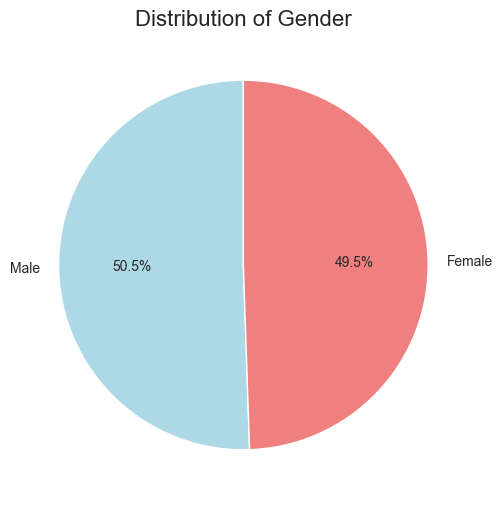

In [ ]:
# Create a pie chart that shows the overall distribution of Gender in the dataset
plt.figure(figsize=(8, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=['lightblue', 'lightcoral'],
    startangle=90
)
# Add a title
plt.title('Distribution of Gender', fontsize=16)

plt.show()


#### Pie Chart using Plotly Express

In [ ]:
# The parameter category_orders is used in this example to sorts the categories in ascending order
fig = px.pie(
    data_frame=sleep_df,
    names='Stress Level',
    category_orders={'Stress Level': set(sleep_df['Stress Level'])},
    title='Distribution of Stress Levels'
)
fig.show()

#### Pairwise Scatter Plots using seaborn (and matplotlib)

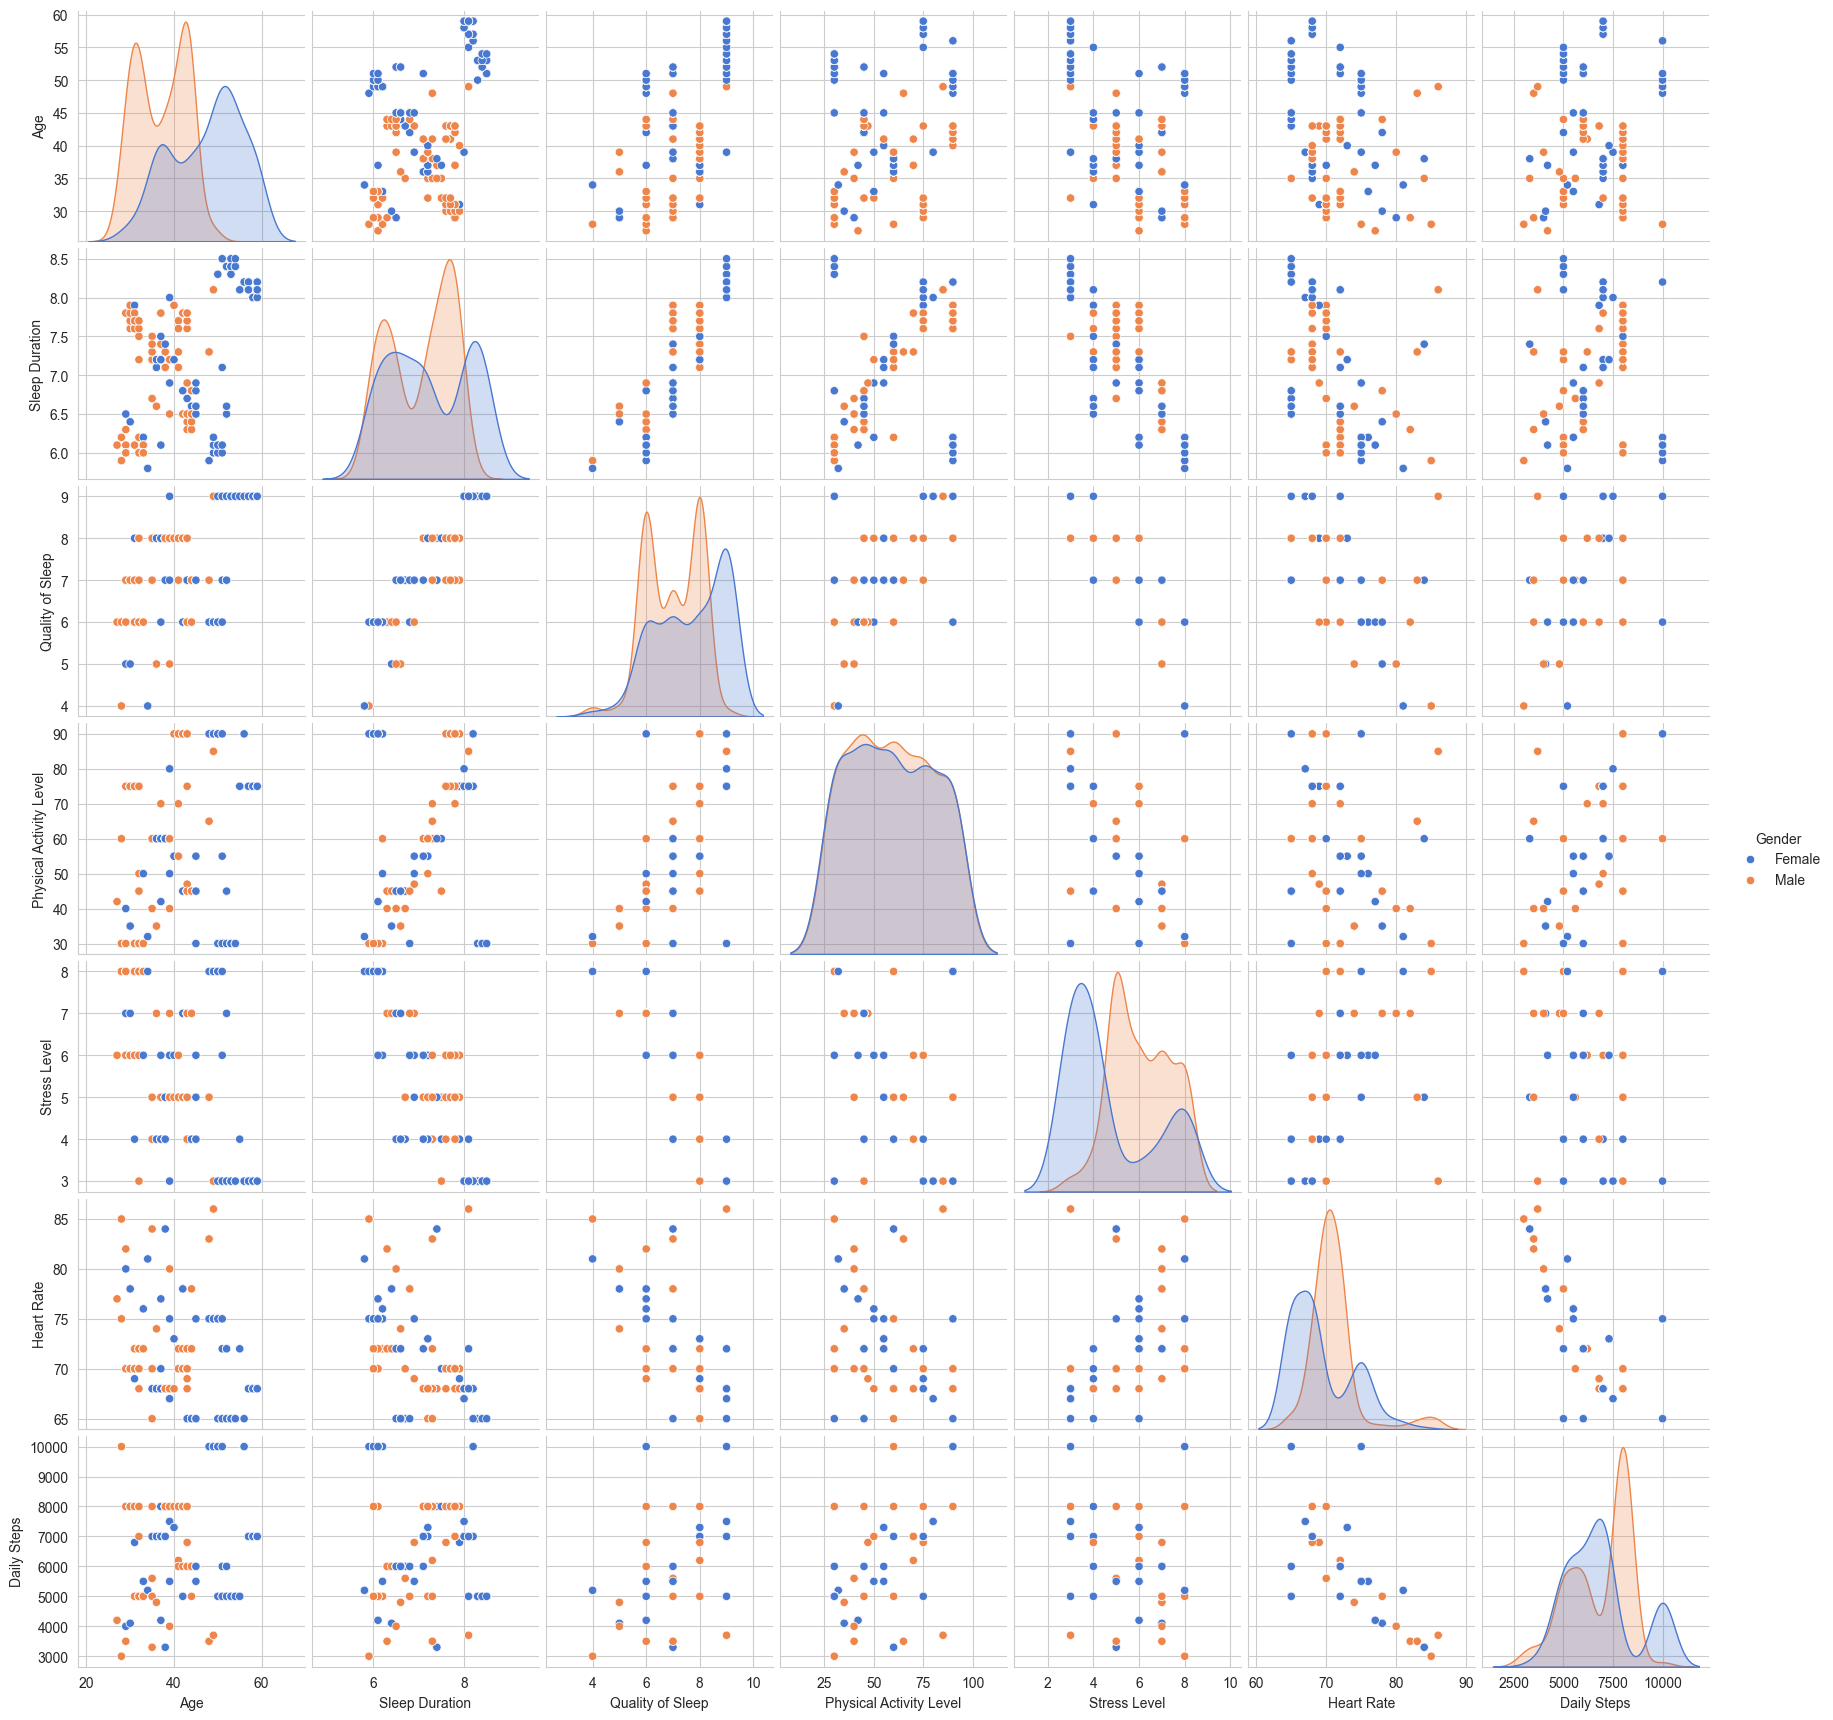

In [ ]:
# Plot all numerical values against each other pairwise.
# We use the 'Gender' category for the color hue.
# We don't want to plot the 'Person ID' column, so we drop it.
sns.pairplot(
    data=sleep_df.drop(['Person ID'], axis=1),
    hue='Gender',
    palette='muted'
)
plt.show()

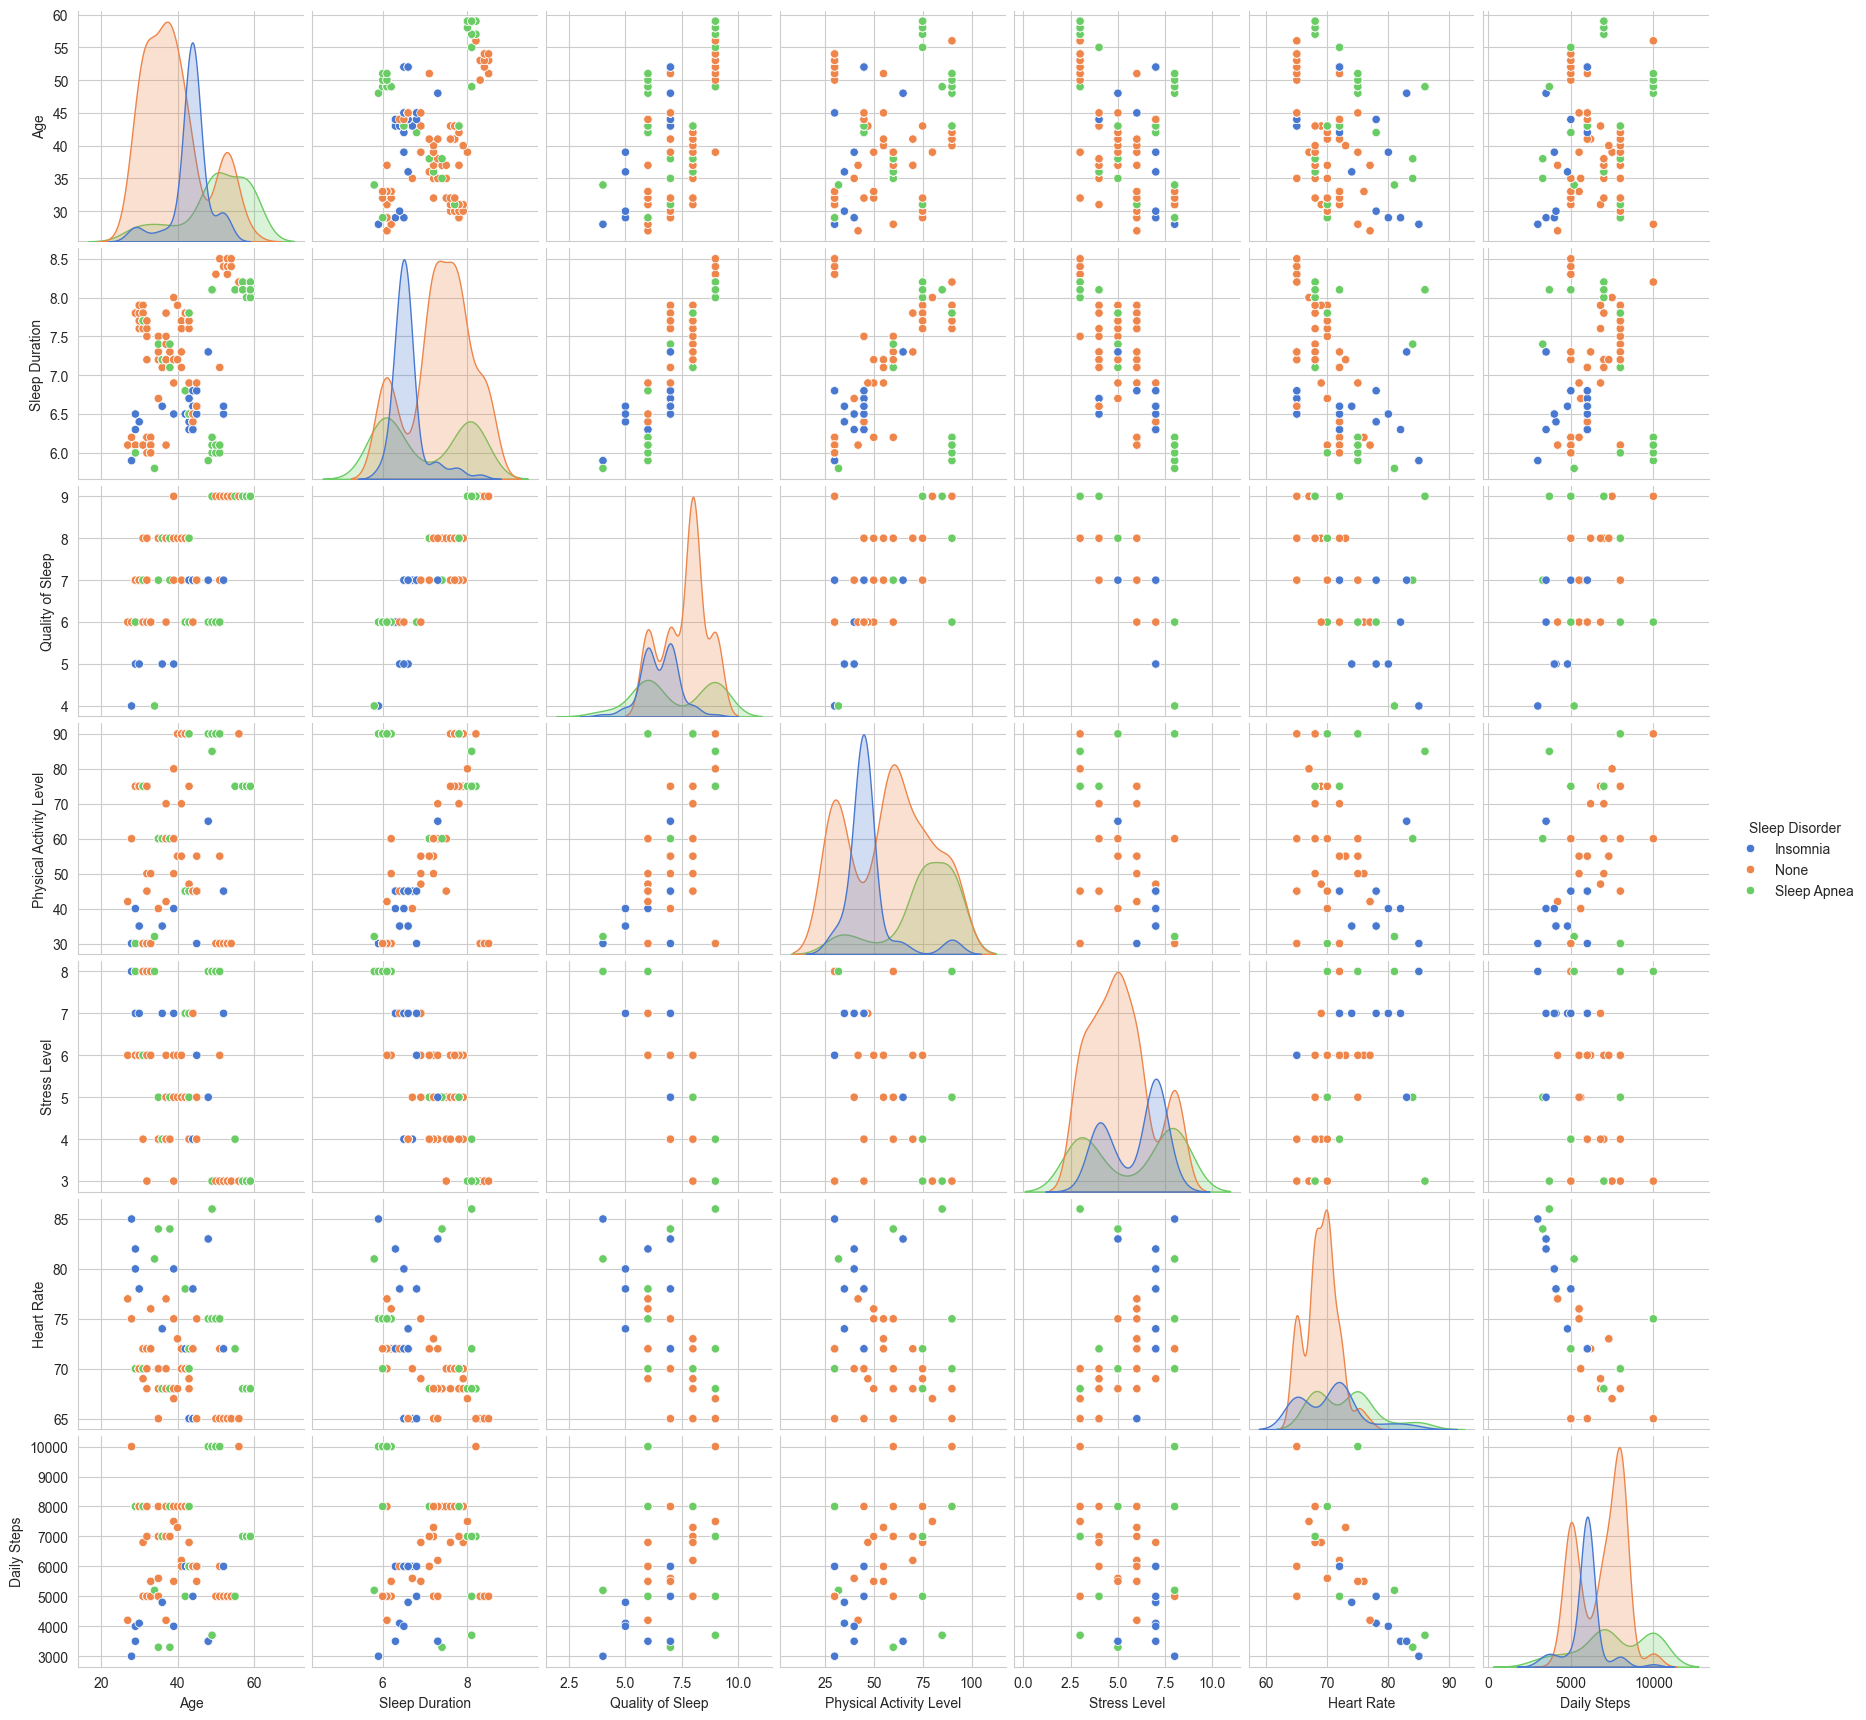

In [ ]:
# We could do the same using the 'Sleep Disorder' category for the color hue.
sns.pairplot(
    data=sleep_df.drop(['Person ID'], axis=1),
    hue='Sleep Disorder',
    palette='muted'
)
plt.show()

### Enter the Playground

You can find a large gallery of visualization examples including ready Python code on the following website:

[The Python Graph Gallery](https://python-graph-gallery.com)

In [ ]:
# Recall our dataframe
sleep_df.describe(include="all").style

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP Type
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,374,374
unique,nan,2,nan,11,nan,nan,nan,nan,4,25,nan,nan,3,4
top,nan,Male,nan,Nurse,nan,nan,nan,nan,Normal,130/85,nan,nan,None,Normal
freq,nan,189,nan,73,nan,nan,nan,nan,195,99,nan,nan,219,121
mean,187.500000,nan,42.184492,nan,7.132086,7.312834,59.171123,5.385027,nan,nan,70.165775,6816.844920,nan,nan
std,108.108742,nan,8.673133,nan,0.795657,1.196956,20.830804,1.774526,nan,nan,4.135676,1617.915679,nan,nan
min,1.000000,nan,27.000000,nan,5.800000,4.000000,30.000000,3.000000,nan,nan,65.000000,3000.000000,nan,nan
25%,94.250000,nan,35.250000,nan,6.400000,6.000000,45.000000,4.000000,nan,nan,68.000000,5600.000000,nan,nan
50%,187.500000,nan,43.000000,nan,7.200000,7.000000,60.000000,5.000000,nan,nan,70.000000,7000.000000,nan,nan
75%,280.750000,nan,50.000000,nan,7.800000,8.000000,75.000000,7.000000,nan,nan,72.000000,8000.000000,nan,nan


#### Example: Boxplot

https://python-graph-gallery.com/boxplot/

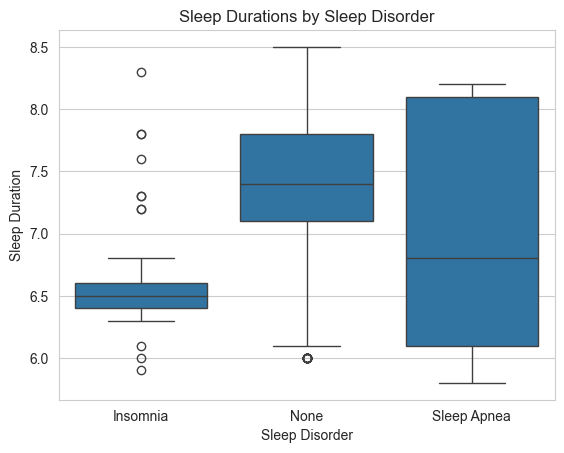

In [ ]:
sns.boxplot(
    data=sleep_df,
    x='Sleep Disorder',
    y='Sleep Duration'
)
plt.title('Sleep Durations by Sleep Disorder')
plt.show()

If you want to have an interactive visualization for data exploration, Plotly is your friend:

In [ ]:
# We also want to show all individual data points and separate by Gender
fig = px.box(
    data_frame=sleep_df,
    x='Sleep Disorder',
    y='Sleep Duration',
    points="all",
    title='Sleep Durations by Sleep Disorder',
    color='Gender',
    color_discrete_sequence=px.colors.qualitative.D3
)
fig.show()

### Now it's Your Turn

Try to come up with some meaningful visualizations that give you more insights about the data.

Please add your example to [&rarr; these Google Slides](https://docs.google.com/presentation/d/14eO12P4f3RlYWy3ebwVA64il6OUxV5U260HTaK5WNBs/edit?usp=sharing) (one or two images and a short explanation).

#### Helpful Resources

Visit the following websites for inspiration and help:
- [The Data Visualisation Catalogue](https://datavizcatalogue.com/index.html)
- [The Python Graph Gallery](https://python-graph-gallery.com)
- [From Data to Viz](https://www.data-to-viz.com) (similar to the previous one)
- [Cheat Sheets for Data Visualization Techniques](https://visualizationcheatsheets.github.io)

If you need more information about pandas Dataframes:
- [pandas documentation](https://pandas.pydata.org/docs/)

In [ ]:
sns.boxplot(
    data=sleep_df,
    x='Sleep Disorder',
    y='Sleep Duration'
)
plt.title('Sleep Durations by Sleep Disorder')
plt.show()# Your code here:


---

## Additional Resources

If you are interested in how **not** to visualize:
[Misleading Graphs: Real Life Examples](https://www.statisticshowto.com/probability-and-statistics/descriptive-statistics/misleading-graphs/)

---

<img src="https://imgs.xkcd.com/comics/cant_sleep.png" alt="Can't sleep">

Image sources: https://xkcd.com